<a href="https://colab.research.google.com/github/MadisonJBollinger/lis5693/blob/main/Lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lab 5: Topic Modeling
I have chosen the topic of church in Lens as I work for a church and we recently
had our Regional Assembly that discussed various topics, including ideas like AI
and utlizing church data to better utilize resources. In Lens Search Query, I
started with just "Church" and after a look through, I narrowed it further by adding
AND "tithes", it limited it to less than 1,000 so I changed it to "attendance",
which provided over 2,000 results.

Pre-Tasks: This is the Installation coding

In [ ]:
!pip install gensim
!pip install pyldavis
!pip install nltk

In [ ]:
import nltk
nltk.download('stopwords')

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import pandas as pd
from nltk.corpus import stopwords
import string
import gensim.corpora as corpora
from gensim.models import LdaModel
import pyLDAvis.gensim_models
pyLDAvis.enable_notebook()
import warnings
warnings.filterwarnings("ignore")

Task 1: I will now import the data obtained by my Lens' query

In [174]:
import requests
import io

url = "https://raw.githubusercontent.com/MadisonJBollinger/lis5693/main/lab-5/church-attendance.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

In [175]:
import pandas as pd

df = pd.read_csv(io.StringIO(text))
print(df.columns)
#this will tell me all the columns without the data under them, to give me an easy
#idea of what to look at.

Index(['Lens ID', 'Title', 'Date Published', 'Publication Year',
       'Publication Type', 'Source Title', 'ISSNs', 'Publisher',
       'Source Country', 'Author/s', 'Abstract', 'Volume', 'Issue Number',
       'Start Page', 'End Page', 'Fields of Study', 'Keywords', 'MeSH Terms',
       'Chemicals', 'Funding', 'Source URLs', 'External URL', 'PMID', 'DOI',
       'Microsoft Academic ID', 'PMCID', 'Citing Patents Count', 'References',
       'Citing Works Count', 'Is Open Access', 'Open Access License',
       'Open Access Colour'],
      dtype='object')


Task 2

In [176]:
df = df[["Publication Year", "Abstract", "MeSH Terms"]]
df
print(df.head(10))

   Publication Year                                           Abstract  \
0            1949.0  "Congress shall make no law respecting an esta...   
1            2017.0  British Columbia is at the forefront of a secu...   
2            2017.0  All of the 50 states of the United States have...   
3            1994.0  Hadaway, Marler et Chaves ont recemment affirm...   
4            1919.0  JSTOR is a not-for-profit service that helps s...   
5            2025.0  <p>Experiments, with their ability to establis...   
6            2019.0  Abstract Objective To examine church leaders’ ...   
7            1996.0  The influence of religion on attitudes toward ...   
8            2018.0                                                NaN   
9            1964.0  Analysis of the responses of a combined sample...   

                                          MeSH Terms  
0                                                NaN  
1                                                NaN  
2  Child; Health Pol

In [177]:
df["Abstract"] = df["Abstract"].fillna("")
docs = df.Abstract.tolist()
print(docs[0])

"Congress shall make no law respecting an establishment of religion, or prohibiting the free exercise thereof. ...." In a number of recent cases the Supreme Court has attempted to determine, in specific references, the present meaning of those words. The writer of this paper would like to record, concerning opinions expressed by members of the Court in the discussion of these cases, some reflections which have arisen out of a long participation in the teaching of American college and adult classes.


I chose Publication Year, Abstract, and MeSH Terms to help determine the best one for modeling. Based on the information provided I believe Abstract will be the best. Mesh Terms showed only 30% of the results had terms attached and Publicaiton year was not providing enough information to comfortably do a model.

Task 3

In [178]:
stop_words = stopwords.words('english')

In [179]:
def clean_doc(doc):
    no_punct = ''
    for c in doc:
        if c not in string.punctuation:
            no_punct = no_punct+c
    # with list comprehension
    # no_punct = ''.join([c for c in doc if c not in string.punctuation])

    words = no_punct.lower().split()

    final_words = []
    for word in words:
        if word not in stop_words:
            final_words.append(word)

    # with list comprehension
    # final_words = [word for word in words if word not in stop_words]

    return final_words

In [221]:
## Adding custom stopwords

custom_stopwords = ['church','churches', 'religious', 'attendance', 'study', 'social', 'data', 'research']
stop_words.extend(custom_stopwords)
print(f"New stopwords added: {custom_stopwords}")

New stopwords added: ['church', 'churches', 'religious', 'attendance', 'study', 'social', 'data', 'research']


In [222]:
cleaned_docs = [clean_doc(doc) for doc in docs]
id2word = corpora.Dictionary(cleaned_docs)
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]

print("Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.")

cleaned_with_custom_stopwords = clean_doc(docs[0])
print("\nOriginal document (first one):")
print(docs[0])
print("\nCleaned document with custom stopwords:")
print(cleaned_with_custom_stopwords)

Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.

Original document (first one):
"Congress shall make no law respecting an establishment of religion, or prohibiting the free exercise thereof. ...." In a number of recent cases the Supreme Court has attempted to determine, in specific references, the present meaning of those words. The writer of this paper would like to record, concerning opinions expressed by members of the Court in the discussion of these cases, some reflections which have arisen out of a long participation in the teaching of American college and adult classes.

Cleaned document with custom stopwords:
['congress', 'shall', 'make', 'law', 'respecting', 'establishment', 'religion', 'prohibiting', 'free', 'exercise', 'thereof', 'number', 'recent', 'cases', 'supreme', 'court', 'attempted', 'determine', 'specific', 'references', 'present', 'meaning', 'words', 'writer', 'paper', 'would', 'like', 'record', 'concerning', 'opinions', 'expres

In [223]:
cleaned_docs = [clean_doc(doc) for doc in docs]

In [224]:
id2word = corpora.Dictionary(cleaned_docs)

In [225]:
id2word[250]

'hadaway'

In [226]:
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]

In [227]:
print(corpus[0])

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 2), (5, 1), (6, 1), (7, 1), (8, 1), (9, 2), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (40, 1), (41, 1)]


In [228]:
for num in corpus[0]:
    num = num[0]
    print(f"{num}\t{id2word[num]}")

0	adult
1	american
2	arisen
3	attempted
4	cases
5	classes
6	college
7	concerning
8	congress
9	court
10	determine
11	discussion
12	establishment
13	exercise
14	expressed
15	free
16	law
17	like
18	long
19	make
20	meaning
21	members
22	number
23	opinions
24	paper
25	participation
26	present
27	prohibiting
28	recent
29	record
30	references
31	reflections
32	religion
33	respecting
34	shall
35	specific
36	supreme
37	teaching
38	thereof
39	words
40	would
41	writer


In [229]:
lda_model_10 = LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=10,
    random_state=42,
    passes=15,
    iterations=100
)

In [230]:
lda_model_20 = LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=20,
    random_state=42,
    passes=15,
    iterations=100
)

I added additional instructions because i was getting a warning so I made it this wat to avoid it.

In [231]:
topics_20 = lda_model_20.get_document_topics(corpus)
len(topics_20)

1000

In [233]:
print("===== 10-TOPIC MODEL =====")
for i in range(10):
    print(f"Topic {i+1}:")
    print(lda_model_10.show_topic(i, topn=5))
    print()

print("===== 20-TOPIC MODEL =====")
for i in range(20):
    print(f"Topic {i+1}:")
    print(lda_model_20.show_topic(i, topn=5))
    print()

===== 10-TOPIC MODEL =====
Topic 1:
[('school', np.float32(0.006001695)), ('worship', np.float32(0.0054045855)), ('sabbath', np.float32(0.004542952)), ('new', np.float32(0.004382649)), ('factors', np.float32(0.0037333888))]

Topic 2:
[('support', np.float32(0.01971566)), ('members', np.float32(0.006115889)), ('black', np.float32(0.005950247)), ('findings', np.float32(0.0056045437)), ('relationship', np.float32(0.0054110377))]

Topic 3:
[('health', np.float32(0.0062238215)), ('among', np.float32(0.004958862)), ('also', np.float32(0.0038151862)), ('new', np.float32(0.00359764)), ('leaders', np.float32(0.0034626378))]

Topic 4:
[('content', np.float32(0.0067245597)), ('francis', np.float32(0.00631154)), ('taylor', np.float32(0.006038903)), ('members', np.float32(0.0052002226)), ('views', np.float32(0.0050609945))]

Topic 5:
[('voluntary', np.float32(0.005384651)), ('organizations', np.float32(0.0046688975)), ('laws', np.float32(0.0042683934)), ('participation', np.float32(0.004223488)), (

Based on the topics printed, the 10-model shows things like 'voluntary', 'school', and 'member'. The 20-model has topics like, 'pandemic', 'among', and 'content'. It also brings up at least one denomination and a variety of ages. This makes it easy to decide that the 20 model is best as there is more details and easy keywords to work with.

Task 4

In [238]:
topic_data = []
target_topic_ids = [4, 9, 14, 19]

for topic_id in target_topic_ids:
    # Retrieve the top 10 words and their probabilities for the current topic
    topic_terms = lda_model_20.show_topic(topic_id, topn=10)

    for word, prob in topic_terms:
        topic_data.append({
            'Topic ID': topic_id +1,
            'Word': word,
            'Probability': prob
        })

df_topic_words = pd.DataFrame(topic_data)
print("DataFrame 'df_topic_words' created successfully with topic words and probabilities.")
print(df_topic_words.head())

DataFrame 'df_topic_words' created successfully with topic words and probabilities.
   Topic ID      Word  Probability
0         5       one     0.006244
1         5   support     0.004976
2         5  religion     0.003954
3         5   beecher     0.003079
4         5     force     0.003078


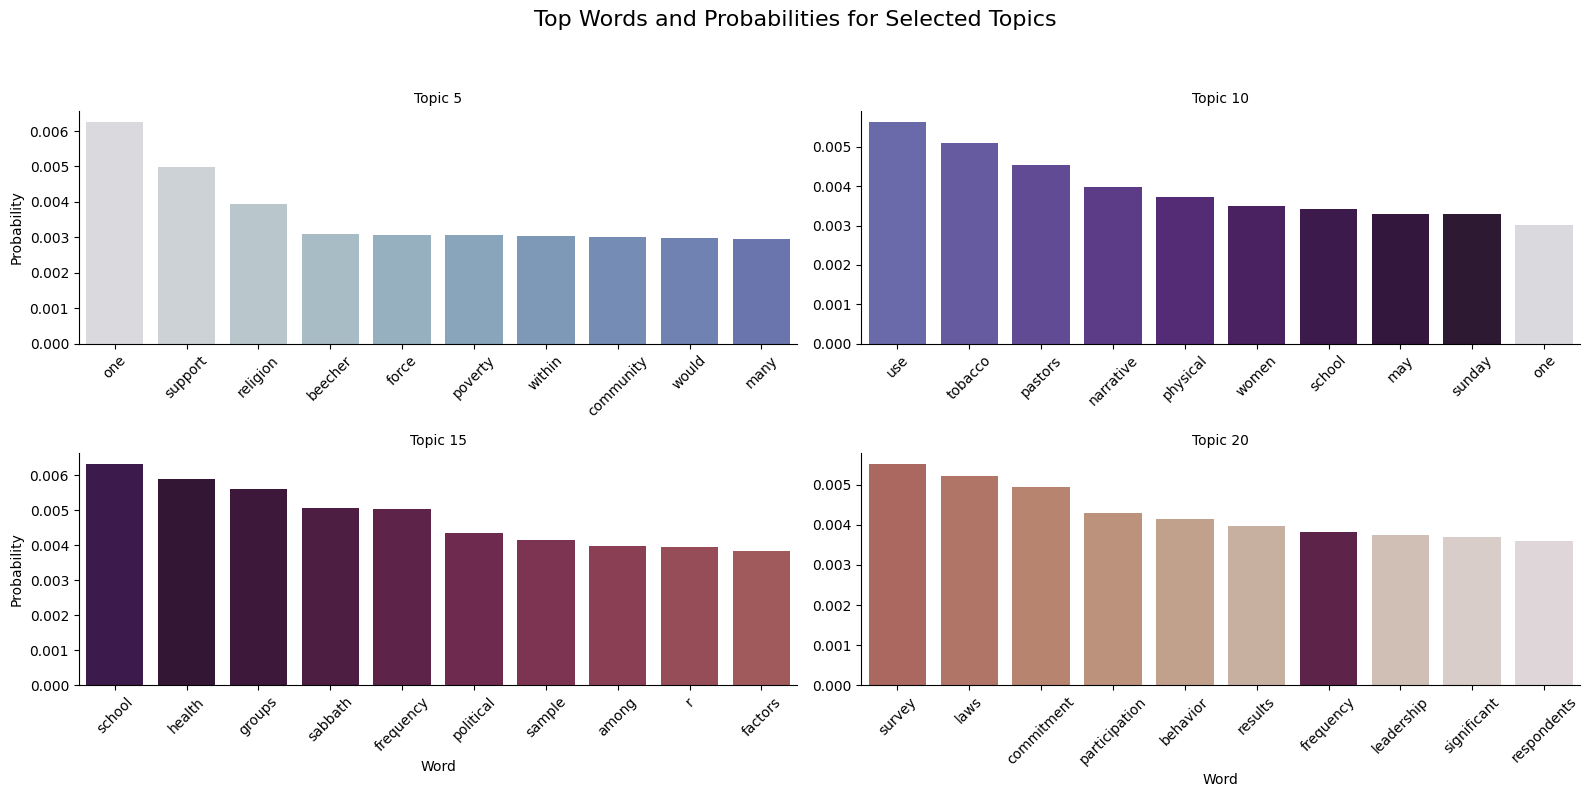

In [239]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the facet bar plot
g = sns.catplot(data=df_topic_words, x='Word', y='Probability', col='Topic ID', col_wrap=2, kind='bar',
                height=4, aspect=2, hue='Word', legend=False, palette='twilight', sharex=False, sharey=False)

# Customize the plot
g.set_axis_labels("Word", "Probability")
g.set_titles("Topic {col_name}")

# Rotate x-axis labels for better readability
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    ax.tick_params(axis='x', labelbottom=True)

plt.suptitle('Top Words and Probabilities for Selected Topics', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()



In [241]:
vis = pyLDAvis.gensim_models.prepare(lda_model_20, corpus, id2word, mds="mmds", R=30)


In [242]:
vis

PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
16    -0.094104 -0.018257       1        1  8.965058
10    -0.195377  0.022490       2        1  8.719194
2     -0.017491 -0.217138       3        1  7.599895
6     -0.076869 -0.116575       4        1  7.228994
5     -0.009807  0.140428       5        1  6.585344
7     -0.070296  0.081122       6        1  6.173237
19    -0.185833  0.107717       7        1  5.897426
15    -0.163731 -0.144081       8        1  5.255714
3      0.025551 -0.305823       9        1  4.784781
17     0.106283 -0.170266      10        1  4.703706
13     0.028270 -0.058215      11        1  4.497426
14     0.087518  0.183759      12        1  4.438527
9     -0.252959 -0.081156      13        1  4.098005
0      0.116963  0.050723      14        1  4.065648
1     -0.135877  0.198680      15        1  3.845383
11    -0.018312  0.273779      16        1  3.306898
8      0.159778 -0.078700      17        1  3.196807
12     0.243719 -0.077619      18        1  2.664676
4      0.262893  0.051427      19        1  2.382167
18     0.189681  0.157705      20        1  1.591115, topic_info=         Term        Freq       Total Category  logprob  loglift
7162    greek   94.000000   94.000000  Default  30.0000  30.0000
9789   greece   56.000000   56.000000  Default  29.0000  29.0000
407    health  190.000000  190.000000  Default  28.0000  28.0000
283   content   54.000000   54.000000  Default  27.0000  27.0000
205   schools   56.000000   56.000000  Default  26.0000  26.0000
...       ...         ...         ...      ...      ...      ...
40      would    2.925906   89.335540  Topic20  -5.9547   0.7219
1278  factors    2.888154  138.606567  Topic20  -5.9677   0.2697
115    people    2.662103  181.940335  Topic20  -6.0492  -0.0838
1076    lower    2.659758   60.883425  Topic20  -6.0500   1.0100
906   beliefs    2.659748   69.539192  Topic20  -6.0500   0.8771

[1478 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
5641      6  0.897002        0001
6199     11  0.798848         005
2331     16  0.620872          02
2333      8  0.348871          09
2333     16  0.523307          09
...     ...       ...         ...
8032      8  0.784764  “business”
3258      3  0.629700        “the
3258     13  0.104950        “the
3258     14  0.104950        “the
3258     16  0.104950        “the

[5569 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[17, 11, 3, 7, 6, 8, 20, 16, 4, 18, 14, 15, 10, 1, 2, 12, 9, 13, 5, 19])

### Task 4: Topic Interpretation

Topic 5: Religious Influence and Social Support  

Topic 10: Health Behaviors and Pastoral Influence  


Topic 15: School and Religious Participation  


Topic 20: Survey-Based Religious Behavior and Commitment  


10 and 15 are distinct as they focus on health or adolescence. 5 and 20 focus on participation. In all they seemed typical, though I never thought about survey usage.

### Reflection

This assignment went well because I was able to successfully load a large dataset from Lens.org and apply topic modeling techniques to identify patterns in the data. One challenge I encountered was refining stopwords as I kept having to go back.

Topic modeling could be useful in my work in a church setting by helping analyze trends in attendance, survey responses, or research articles. This could provide insights into community engagement, health-related influences, and participation patterns, allowing for better decision-making and resource allocation. I find that I related a lot of what was going on to what I do especially in outreach.